# Change Point Detection — Signal Event Boundaries

Fetch the last 3 hours of mag_report data from a sensor and use **change point detection** to find where flow signals begin and end.

Methods:
- **PELT** (Pruned Exact Linear Time) — penalized cost-based segmentation via `ruptures`
- **BOCPD** (Bayesian Online Change Point Detection) — probabilistic, streaming-friendly

The goal: visually see where the algorithm predicts signal onsets in the raw stream.

In [20]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "requests", "numpy", "pandas", "scipy", "matplotlib", "ruptures"])


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


0

In [21]:
import requests
import numpy as np
import pandas as pd
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt
import ruptures as rpt

HASURA_URL = "https://hasura.pipestuesday.org/v1/graphql"
HASURA_ADMIN_SECRET = "PIPE_SUPERMMMSECRET_PIPE"
HEADERS = {
    "Content-Type": "application/json",
    "x-hasura-admin-secret": HASURA_ADMIN_SECRET,
}

def gql_query(query: str, variables: dict = None) -> dict:
    payload = {"query": query}
    if variables:
        payload["variables"] = variables
    resp = requests.post(HASURA_URL, json=payload, headers=HEADERS)
    resp.raise_for_status()
    body = resp.json()
    if "errors" in body:
        raise RuntimeError(f"GraphQL errors: {body['errors']}")
    return body["data"]

print("Hasura client ready")

Hasura client ready


## 1. Pick a Sensor & Fetch Last 3 Hours of Data

In [22]:
# List available sensors with their LATEST reading time
sensors = []
sensor_ids = gql_query("""
query {
  mag_report(distinct_on: sensor_id, order_by: {sensor_id: asc}) {
    sensor_id
  }
}
""")["mag_report"]

for s in sensor_ids:
    sid = s["sensor_id"]
    latest = gql_query("""
    query Latest($sid: bigint!) {
      mag_report(where: {sensor_id: {_eq: $sid}}, order_by: {created_at: desc}, limit: 1) {
        created_at
      }
    }
    """, variables={"sid": str(sid)})["mag_report"]
    ts = latest[0]["created_at"] if latest else "no data"
    sensors.append({"sensor_id": sid, "latest": ts})

print(f"{'Sensor ID':<12} {'Latest Reading'}")
print("-" * 40)
for s in sensors:
    print(f"{s['sensor_id']:<12} {s['latest']}")

Sensor ID    Latest Reading
----------------------------------------
6            2026-03-29T21:42:01.868+00:00
9            2026-03-27T19:10:06.979+00:00


In [23]:
# --- CONFIGURE ---
SENSOR_ID = 6           # only sensor with data
MINUTES_BACK = 5        # how many minutes of history to fetch
# -----------------

now = datetime.now(timezone.utc)
since = now - timedelta(minutes=MINUTES_BACK)

mag_data = gql_query("""
query GetMag($sensor_id: bigint!, $since: timestamptz!) {
  mag_report(
    where: {
      sensor_id: {_eq: $sensor_id}
      created_at: {_gte: $since}
    }
    order_by: {created_at: asc}
    limit: 100000
  ) {
    created_at
    x_axis_reading
  }
}
""", variables={"sensor_id": str(SENSOR_ID), "since": since.isoformat()})

reports = mag_data["mag_report"]
print(f"Sensor {SENSOR_ID}: {len(reports)} readings in last {MINUTES_BACK}min")

if len(reports) == 0:
    print("No recent data — fetching the last available window instead...")
    latest = gql_query("""
    query Latest($sid: bigint!) {
      mag_report(where: {sensor_id: {_eq: $sid}}, order_by: {created_at: desc}, limit: 1) {
        created_at
      }
    }
    """, variables={"sid": str(SENSOR_ID)})["mag_report"]

    if latest:
        end_time = pd.to_datetime(latest[0]["created_at"])
        start_time = end_time - timedelta(minutes=MINUTES_BACK)
        print(f"  Using window: {start_time} -> {end_time}")

        reports = gql_query("""
        query GetMag($sensor_id: bigint!, $since: timestamptz!, $until: timestamptz!) {
          mag_report(
            where: {
              sensor_id: {_eq: $sensor_id}
              created_at: {_gte: $since, _lte: $until}
            }
            order_by: {created_at: asc}
            limit: 100000
          ) {
            created_at
            x_axis_reading
          }
        }
        """, variables={"sensor_id": str(SENSOR_ID),
                        "since": start_time.isoformat(),
                        "until": end_time.isoformat()})["mag_report"]
        print(f"  Got {len(reports)} readings")
    else:
        raise RuntimeError(f"Sensor {SENSOR_ID} has no data at all!")

df = pd.DataFrame(reports)
df["created_at"] = pd.to_datetime(df["created_at"], format="ISO8601")
df["x_axis_reading"] = pd.to_numeric(df["x_axis_reading"], errors="coerce")

print(f"Time range: {df['created_at'].min()} -> {df['created_at'].max()}")
df.head()

Sensor 6: 2527 readings in last 5min
Time range: 2026-03-29 21:37:45.566000+00:00 -> 2026-03-29 21:42:01.868000+00:00


,created_at,x_axis_reading
0,2026-03-29 21:37:45.566000+00:00,-477
1,2026-03-29 21:37:45.666000+00:00,-472
2,2026-03-29 21:37:45.766000+00:00,-483
3,2026-03-29 21:37:45.866000+00:00,-499
4,2026-03-29 21:37:45.966000+00:00,-508


## 2. Raw Signal Overview

Quick look at the full 3h stream to see what we're working with.

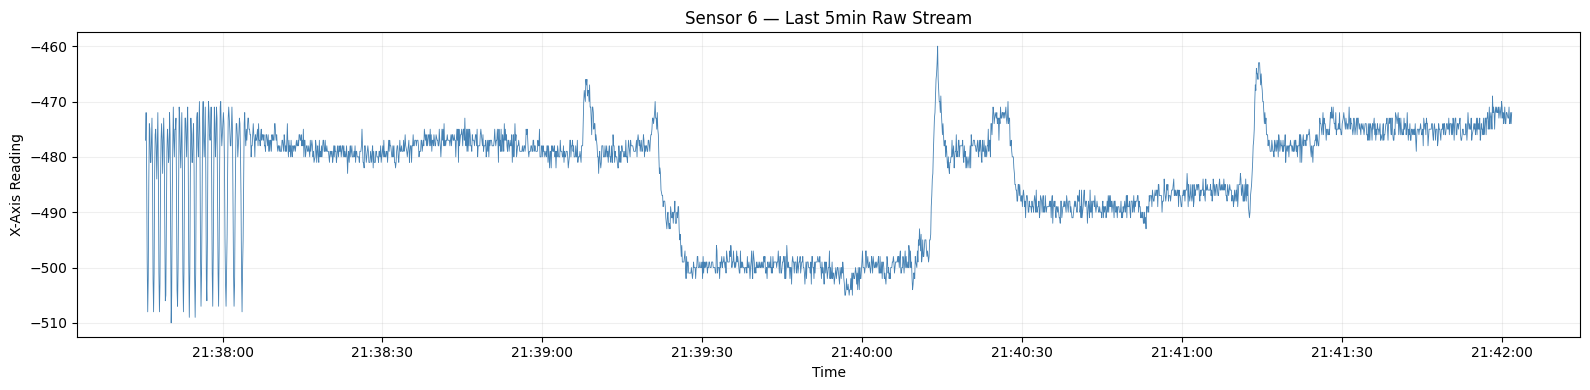

In [24]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(df["created_at"], df["x_axis_reading"], lw=0.6, color="steelblue")
ax.set_ylabel("X-Axis Reading")
ax.set_title(f"Sensor {SENSOR_ID} — Last {MINUTES_BACK}min Raw Stream")
ax.set_xlabel("Time")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 3. PELT Change Point Detection

**PELT** (Pruned Exact Linear Time) finds the optimal set of change points by minimizing a penalized cost function. The `pen` parameter controls sensitivity — lower = more change points detected.

We run it on `x_axis_reading` using an RBF (radial basis function) cost model, which is good for detecting mean+variance shifts.

In [25]:
# Prepare the signal — drop NaNs and work with a clean array
signal = df["x_axis_reading"].dropna().values.astype(float)
timestamps = df.loc[df["x_axis_reading"].notna(), "created_at"].values

# PELT with RBF cost model
# pen (penalty): tune this — higher = fewer change points, lower = more
PENALTY = 3  # <-- adjust this to control sensitivity

algo = rpt.Pelt(model="rbf", min_size=5, jump=1).fit(signal)
change_indices = algo.predict(pen=PENALTY)

# ruptures appends len(signal) as the final "change point" — remove it
if change_indices and change_indices[-1] == len(signal):
    change_indices = change_indices[:-1]

print(f"PELT detected {len(change_indices)} change points (penalty={PENALTY})")
for i, idx in enumerate(change_indices):
    print(f"  CP {i+1}: index {idx}, time {pd.Timestamp(timestamps[idx])}")

PELT detected 23 change points (penalty=3)
  CP 1: index 181, time 2026-03-29 21:38:04.066000
  CP 2: index 296, time 2026-03-29 21:38:15.566000
  CP 3: index 493, time 2026-03-29 21:38:35.566000
  CP 4: index 710, time 2026-03-29 21:38:57.367000
  CP 5: index 812, time 2026-03-29 21:39:07.667000
  CP 6: index 835, time 2026-03-29 21:39:09.967000
  CP 7: index 936, time 2026-03-29 21:39:20.367000
  CP 8: index 951, time 2026-03-29 21:39:21.867000
  CP 9: index 958, time 2026-03-29 21:39:22.667000
  CP 10: index 990, time 2026-03-29 21:39:26.067000
  CP 11: index 1427, time 2026-03-29 21:40:10.367000
  CP 12: index 1452, time 2026-03-29 21:40:12.967000
  CP 13: index 1457, time 2026-03-29 21:40:13.467000
  CP 14: index 1473, time 2026-03-29 21:40:15.067000
  CP 15: index 1564, time 2026-03-29 21:40:24.167000
  CP 16: index 1599, time 2026-03-29 21:40:27.767000
  CP 17: index 1608, time 2026-03-29 21:40:28.667000
  CP 18: index 1859, time 2026-03-29 21:40:53.867000
  CP 19: index 2050, t

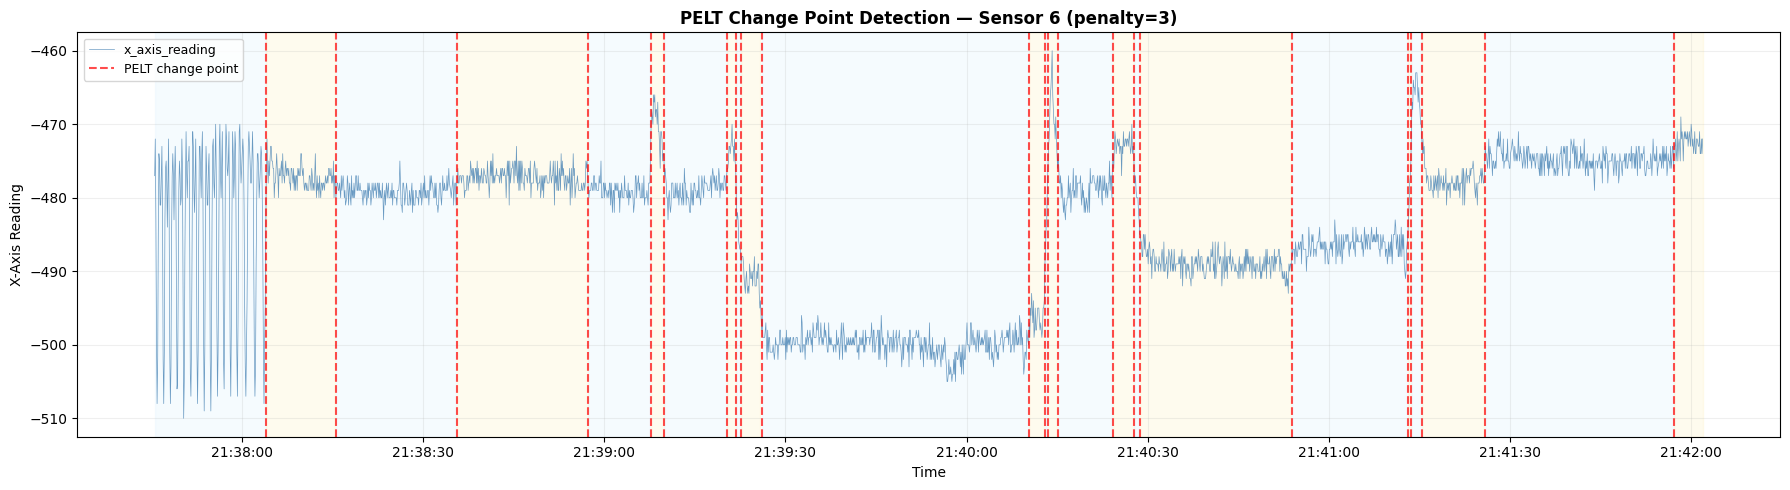

In [26]:
# Visualize PELT change points on the full stream
fig, ax = plt.subplots(figsize=(18, 5))
ts_plot = pd.to_datetime(timestamps)

ax.plot(ts_plot, signal, lw=0.5, color="steelblue", alpha=0.8, label="x_axis_reading")

for i, idx in enumerate(change_indices):
    label = "PELT change point" if i == 0 else None
    ax.axvline(ts_plot[idx], color="red", lw=1.5, ls="--", alpha=0.7, label=label)

# Shade segments with alternating colors
boundaries = [0] + change_indices + [len(signal)]
colors = ["#e0f2fe", "#fef3c7"]  # light blue / light yellow alternating
for j in range(len(boundaries) - 1):
    start_i, end_i = boundaries[j], boundaries[j + 1] - 1
    ax.axvspan(ts_plot[start_i], ts_plot[min(end_i, len(ts_plot) - 1)],
               color=colors[j % 2], alpha=0.3)

ax.set_title(f"PELT Change Point Detection — Sensor {SENSOR_ID} (penalty={PENALTY})", fontweight="bold")
ax.set_xlabel("Time")
ax.set_ylabel("X-Axis Reading")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 4. Penalty Sweep — Finding the Right Sensitivity

Try multiple penalty values to see how the number of detected change points varies. This helps you pick a penalty that captures real signal events without over-segmenting noise.

  pen=0.5   → 76 change points
  pen=1     → 60 change points
  pen=2     → 32 change points
  pen=3     → 23 change points
  pen=5     → 14 change points
  pen=10    → 9 change points
  pen=20    → 6 change points
  pen=50    → 4 change points


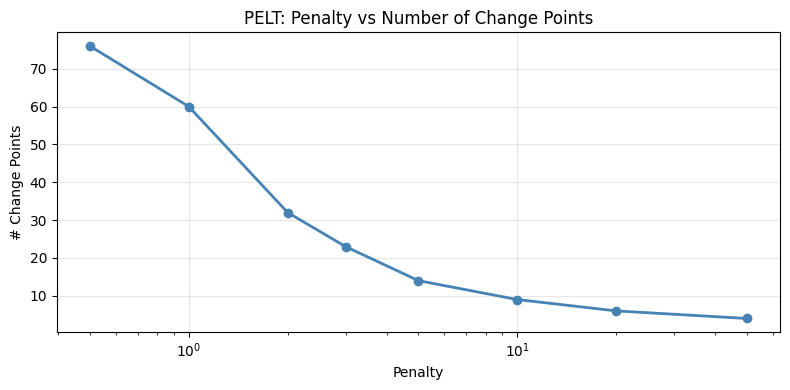

In [27]:
# Sweep penalty values
penalties = [0.5, 1, 2, 3, 5, 10, 20, 50]
results = {}
for pen in penalties:
    cps = algo.predict(pen=pen)
    if cps and cps[-1] == len(signal):
        cps = cps[:-1]
    results[pen] = cps
    print(f"  pen={pen:<5} → {len(cps)} change points")

# Elbow plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(penalties, [len(results[p]) for p in penalties], "o-", color="steelblue", lw=2)
ax.set_xlabel("Penalty")
ax.set_ylabel("# Change Points")
ax.set_title("PELT: Penalty vs Number of Change Points")
ax.set_xscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. BOCPD — Bayesian Online Change Point Detection

A streaming-friendly approach. At each time step, BOCPD maintains a probability distribution over "run lengths" (how long since the last change point). When the run length drops to 0, a change point has occurred.

This implementation uses a Gaussian conjugate prior (Normal-Inverse-Gamma).

In [28]:
from scipy.special import gammaln
from scipy.stats import norm

def bocpd(data, hazard_lambda=200, mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0):
    """
    Bayesian Online Change Point Detection (Adams & MacKay, 2007).
    
    Parameters:
        data: 1D array of observations
        hazard_lambda: expected run length between change points (higher = fewer CPs)
        mu0, kappa0, alpha0, beta0: Normal-Inverse-Gamma prior hyperparameters
    
    Returns:
        R: run length probability matrix (T+1 x T+1)
        maxes: MAP run length at each time step
    """
    T = len(data)
    R = np.zeros((T + 1, T + 1))
    R[0, 0] = 1.0
    
    # Sufficient statistics for the Normal-Inverse-Gamma
    mu = np.array([mu0])
    kappa = np.array([kappa0])
    alpha = np.array([alpha0])
    beta = np.array([beta0])
    
    maxes = np.zeros(T)
    
    H = 1.0 / hazard_lambda  # constant hazard rate
    
    for t in range(T):
        x = data[t]
        
        # Predictive probability: Student-t with updated parameters
        df = 2 * alpha
        scale = np.sqrt(beta * (kappa + 1) / (alpha * kappa))
        # Log predictive probability
        log_pred = (gammaln((df + 1) / 2) - gammaln(df / 2)
                    - 0.5 * np.log(df * np.pi * scale**2)
                    - (df + 1) / 2 * np.log(1 + ((x - mu) / scale)**2 / df))
        pred = np.exp(log_pred)
        
        # Growth probabilities
        R[1:t + 2, t + 1] = R[:t + 1, t] * pred * (1 - H)
        # Change point probability
        R[0, t + 1] = np.sum(R[:t + 1, t] * pred * H)
        # Normalize
        evidence = R[:t + 2, t + 1].sum()
        if evidence > 0:
            R[:t + 2, t + 1] /= evidence
        
        # MAP run length
        maxes[t] = np.argmax(R[:t + 2, t + 1])
        
        # Update sufficient statistics
        new_kappa = kappa + 1
        new_mu = (kappa * mu + x) / new_kappa
        new_alpha = alpha + 0.5
        new_beta = beta + kappa * (x - mu)**2 / (2 * new_kappa)
        
        mu = np.concatenate([[mu0], new_mu])
        kappa = np.concatenate([[kappa0], new_kappa])
        alpha = np.concatenate([[alpha0], new_alpha])
        beta = np.concatenate([[beta0], new_beta])
    
    return R, maxes

print("BOCPD function defined")

BOCPD function defined


In [29]:
# Run BOCPD on the signal
# Standardize first for numerical stability
signal_mean = np.nanmean(signal)
signal_std = np.nanstd(signal)
signal_z = (signal - signal_mean) / max(signal_std, 1e-8)

HAZARD_LAMBDA = 200  # <-- expected samples between change points; tune this

R, maxes = bocpd(signal_z, hazard_lambda=HAZARD_LAMBDA)

# Detect change points: where MAP run length drops back to 0 (or near 0)
bocpd_cps = np.where(np.diff(maxes) < -5)[0] + 1  # run length drops sharply

print(f"BOCPD detected {len(bocpd_cps)} change points (hazard_lambda={HAZARD_LAMBDA})")
for i, idx in enumerate(bocpd_cps[:20]):
    print(f"  CP {i+1}: index {idx}, time {pd.Timestamp(timestamps[idx])}")
if len(bocpd_cps) > 20:
    print(f"  ... and {len(bocpd_cps) - 20} more")

BOCPD detected 33 change points (hazard_lambda=200)
  CP 1: index 159, time 2026-03-29 21:38:01.866000
  CP 2: index 174, time 2026-03-29 21:38:03.366000
  CP 3: index 189, time 2026-03-29 21:38:04.866000
  CP 4: index 398, time 2026-03-29 21:38:25.966000
  CP 5: index 404, time 2026-03-29 21:38:26.566000
  CP 6: index 431, time 2026-03-29 21:38:29.266000
  CP 7: index 456, time 2026-03-29 21:38:31.766000
  CP 8: index 459, time 2026-03-29 21:38:32.066000
  CP 9: index 461, time 2026-03-29 21:38:32.266000
  CP 10: index 592, time 2026-03-29 21:38:45.566000
  CP 11: index 594, time 2026-03-29 21:38:45.766000
  CP 12: index 813, time 2026-03-29 21:39:07.767000
  CP 13: index 844, time 2026-03-29 21:39:10.867000
  CP 14: index 942, time 2026-03-29 21:39:20.967000
  CP 15: index 956, time 2026-03-29 21:39:22.467000
  CP 16: index 995, time 2026-03-29 21:39:26.567000
  CP 17: index 1303, time 2026-03-29 21:39:57.567000
  CP 18: index 1317, time 2026-03-29 21:39:58.967000
  CP 19: index 1319

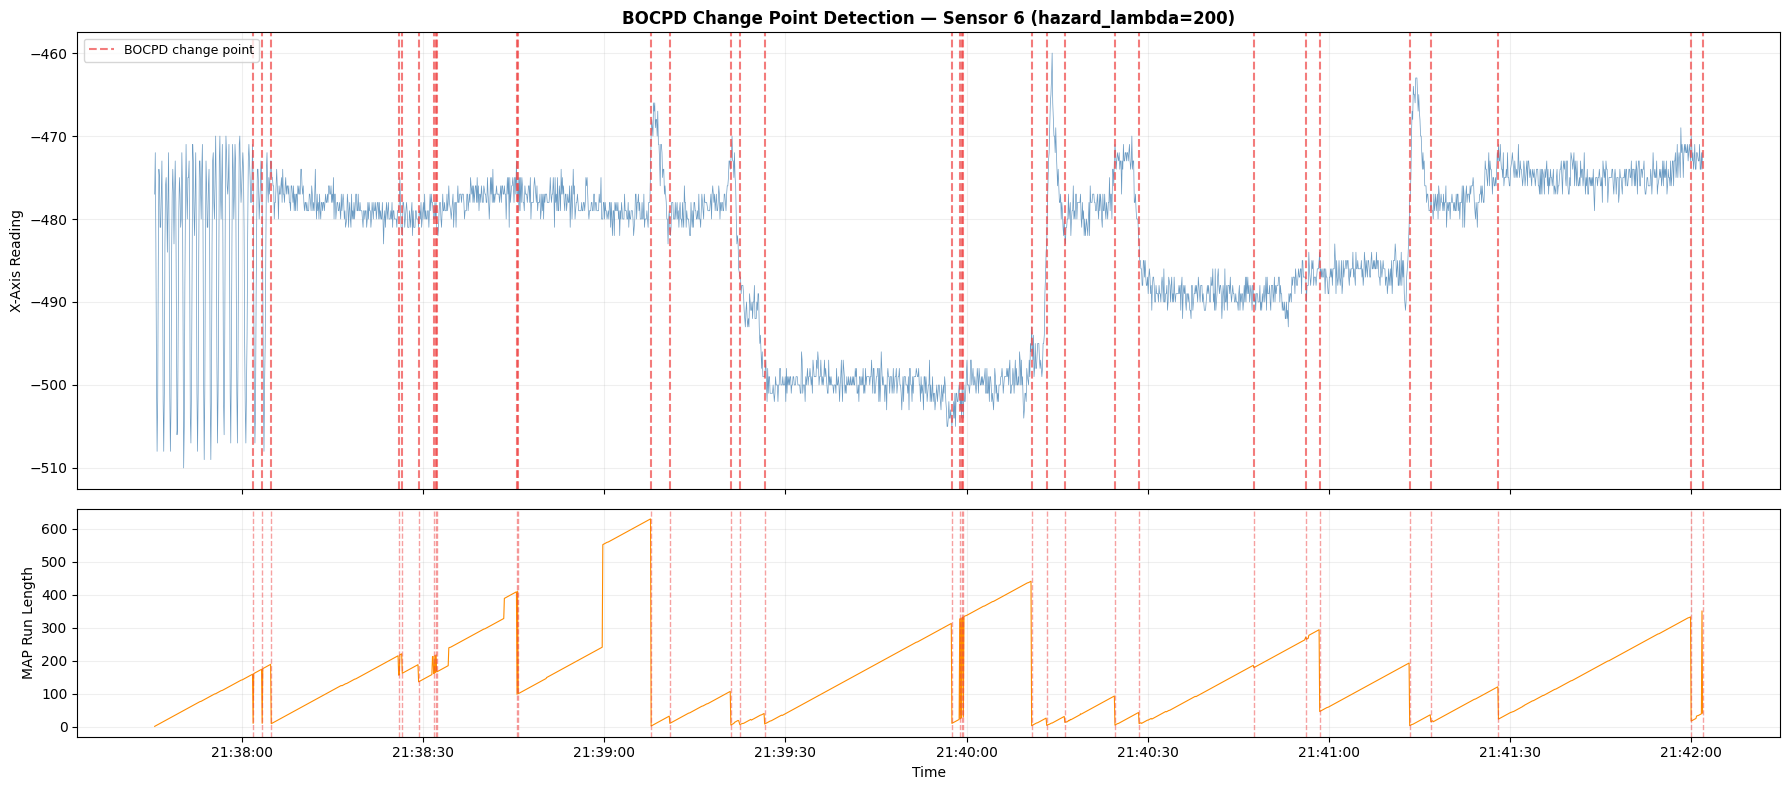

In [30]:
# Visualize BOCPD: signal + run length + change points
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 8), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# Top: signal with BOCPD change points
ax1.plot(ts_plot, signal, lw=0.5, color="steelblue", alpha=0.8)
for i, idx in enumerate(bocpd_cps):
    label = "BOCPD change point" if i == 0 else None
    ax1.axvline(ts_plot[idx], color="#ef4444", lw=1.5, ls="--", alpha=0.7, label=label)
ax1.set_ylabel("X-Axis Reading")
ax1.set_title(f"BOCPD Change Point Detection — Sensor {SENSOR_ID} (hazard_lambda={HAZARD_LAMBDA})",
              fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2)

# Bottom: MAP run length over time
ax2.plot(ts_plot, maxes, lw=0.8, color="darkorange")
ax2.set_ylabel("MAP Run Length")
ax2.set_xlabel("Time")
ax2.grid(True, alpha=0.2)
for idx in bocpd_cps:
    ax2.axvline(ts_plot[idx], color="#ef4444", lw=1, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 6. Side-by-Side Comparison — PELT vs BOCPD

Compare both methods on the same signal to see where they agree (high-confidence event boundaries) and where they disagree.

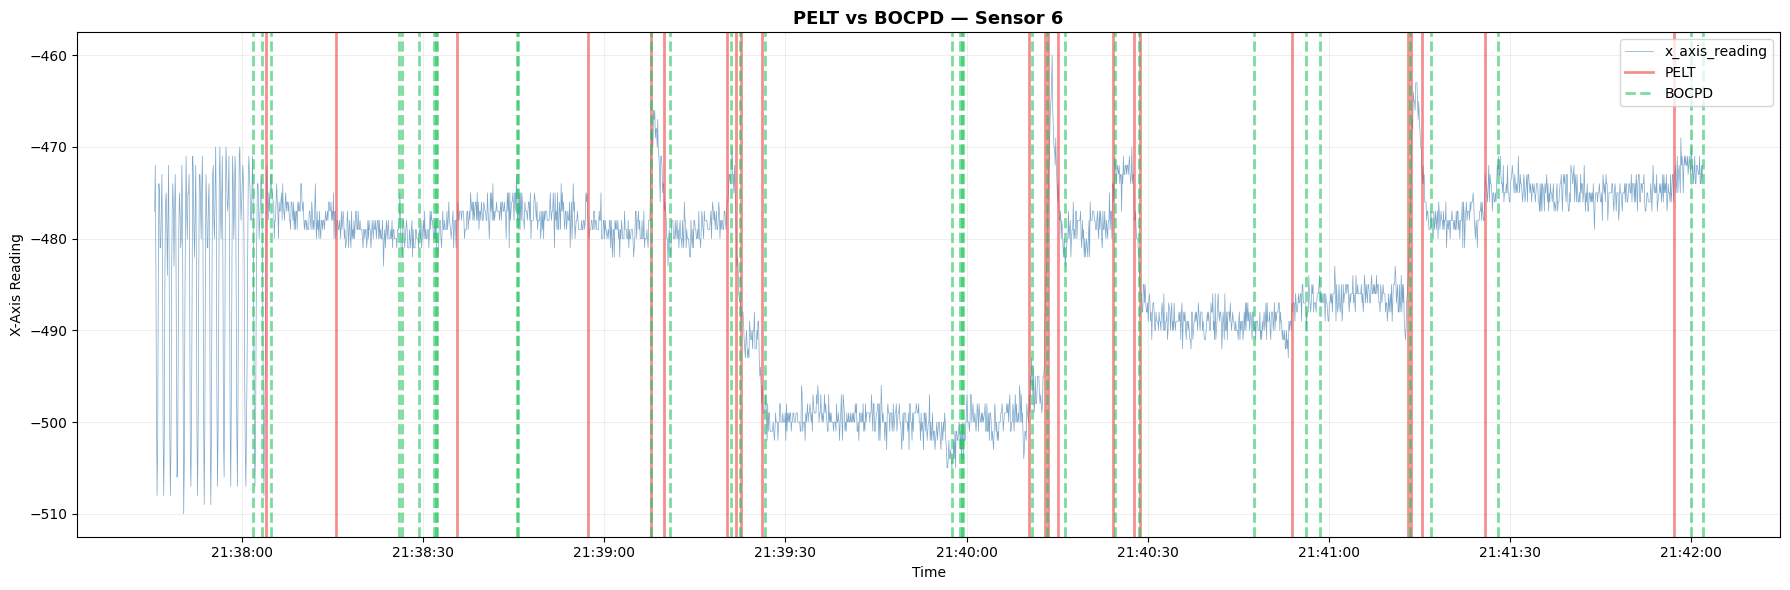


Agreement: 12 change points detected by BOTH methods (within 10 samples)
PELT-only: 11
BOCPD-only: 21


In [31]:
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(ts_plot, signal, lw=0.5, color="steelblue", alpha=0.7, label="x_axis_reading")

# PELT change points
for i, idx in enumerate(change_indices):
    label = "PELT" if i == 0 else None
    ax.axvline(ts_plot[idx], color="#ef4444", lw=2, ls="-", alpha=0.6, label=label)

# BOCPD change points
for i, idx in enumerate(bocpd_cps):
    label = "BOCPD" if i == 0 else None
    ax.axvline(ts_plot[idx], color="#22c55e", lw=2, ls="--", alpha=0.6, label=label)

ax.set_title(f"PELT vs BOCPD — Sensor {SENSOR_ID}", fontweight="bold", fontsize=13)
ax.set_xlabel("Time")
ax.set_ylabel("X-Axis Reading")
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Agreement analysis: find BOCPD CPs within N samples of a PELT CP
TOLERANCE = 10  # samples
agreed = []
for b_idx in bocpd_cps:
    for p_idx in change_indices:
        if abs(b_idx - p_idx) <= TOLERANCE:
            agreed.append((p_idx, b_idx))
            break

print(f"\nAgreement: {len(agreed)} change points detected by BOTH methods (within {TOLERANCE} samples)")
print(f"PELT-only: {len(change_indices) - len(agreed)}")
print(f"BOCPD-only: {len(bocpd_cps) - len(agreed)}")

## 7. Zoom into Detected Events

For each pair of consecutive change points (signal onset → signal end), zoom in to see the event detail. This is where you'd segment out individual flow events.

In [32]:
# Use PELT change points to segment the stream into events
# An "event" = a segment where the signal mean is above the overall median (active period)
median_mag = np.median(signal)

boundaries_full = [0] + list(change_indices) + [len(signal)]
events = []
for j in range(len(boundaries_full) - 1):
    s_i = boundaries_full[j]
    e_i = boundaries_full[j + 1]
    seg = signal[s_i:e_i]
    seg_mean = np.mean(seg)
    if seg_mean > median_mag * 1.05:  # active segment (above baseline)
        events.append({"start": s_i, "end": e_i, "mean": seg_mean, "duration_samples": e_i - s_i})

print(f"Found {len(events)} active event segments (above baseline)")
for i, ev in enumerate(events):
    t0 = pd.Timestamp(timestamps[ev['start']])
    t1 = pd.Timestamp(timestamps[min(ev['end'] - 1, len(timestamps) - 1)])
    dur = (t1 - t0).total_seconds()
    print(f"  Event {i+1}: {t0.strftime('%H:%M:%S')} → {t1.strftime('%H:%M:%S')} ({dur:.0f}s, mean={ev['mean']:.2f})")

Found 24 active event segments (above baseline)
  Event 1: 21:37:45 → 21:38:03 (18s, mean=-484.44)
  Event 2: 21:38:04 → 21:38:15 (11s, mean=-477.08)
  Event 3: 21:38:15 → 21:38:35 (20s, mean=-479.21)
  Event 4: 21:38:35 → 21:38:57 (22s, mean=-477.26)
  Event 5: 21:38:57 → 21:39:07 (10s, mean=-479.07)
  Event 6: 21:39:07 → 21:39:09 (2s, mean=-470.43)
  Event 7: 21:39:09 → 21:39:20 (10s, mean=-478.89)
  Event 8: 21:39:20 → 21:39:21 (1s, mean=-473.73)
  Event 9: 21:39:21 → 21:39:22 (1s, mean=-484.00)
  Event 10: 21:39:22 → 21:39:25 (3s, mean=-490.91)
  Event 11: 21:39:26 → 21:40:10 (44s, mean=-499.90)
  Event 12: 21:40:10 → 21:40:12 (2s, mean=-496.40)
  Event 13: 21:40:12 → 21:40:13 (0s, mean=-484.40)
  Event 14: 21:40:13 → 21:40:14 (2s, mean=-469.06)
  Event 15: 21:40:15 → 21:40:24 (9s, mean=-478.85)
  Event 16: 21:40:24 → 21:40:27 (4s, mean=-472.91)
  Event 17: 21:40:27 → 21:40:28 (1s, mean=-479.67)
  Event 18: 21:40:28 → 21:40:53 (25s, mean=-488.93)
  Event 19: 21:40:53 → 21:41:13 (19

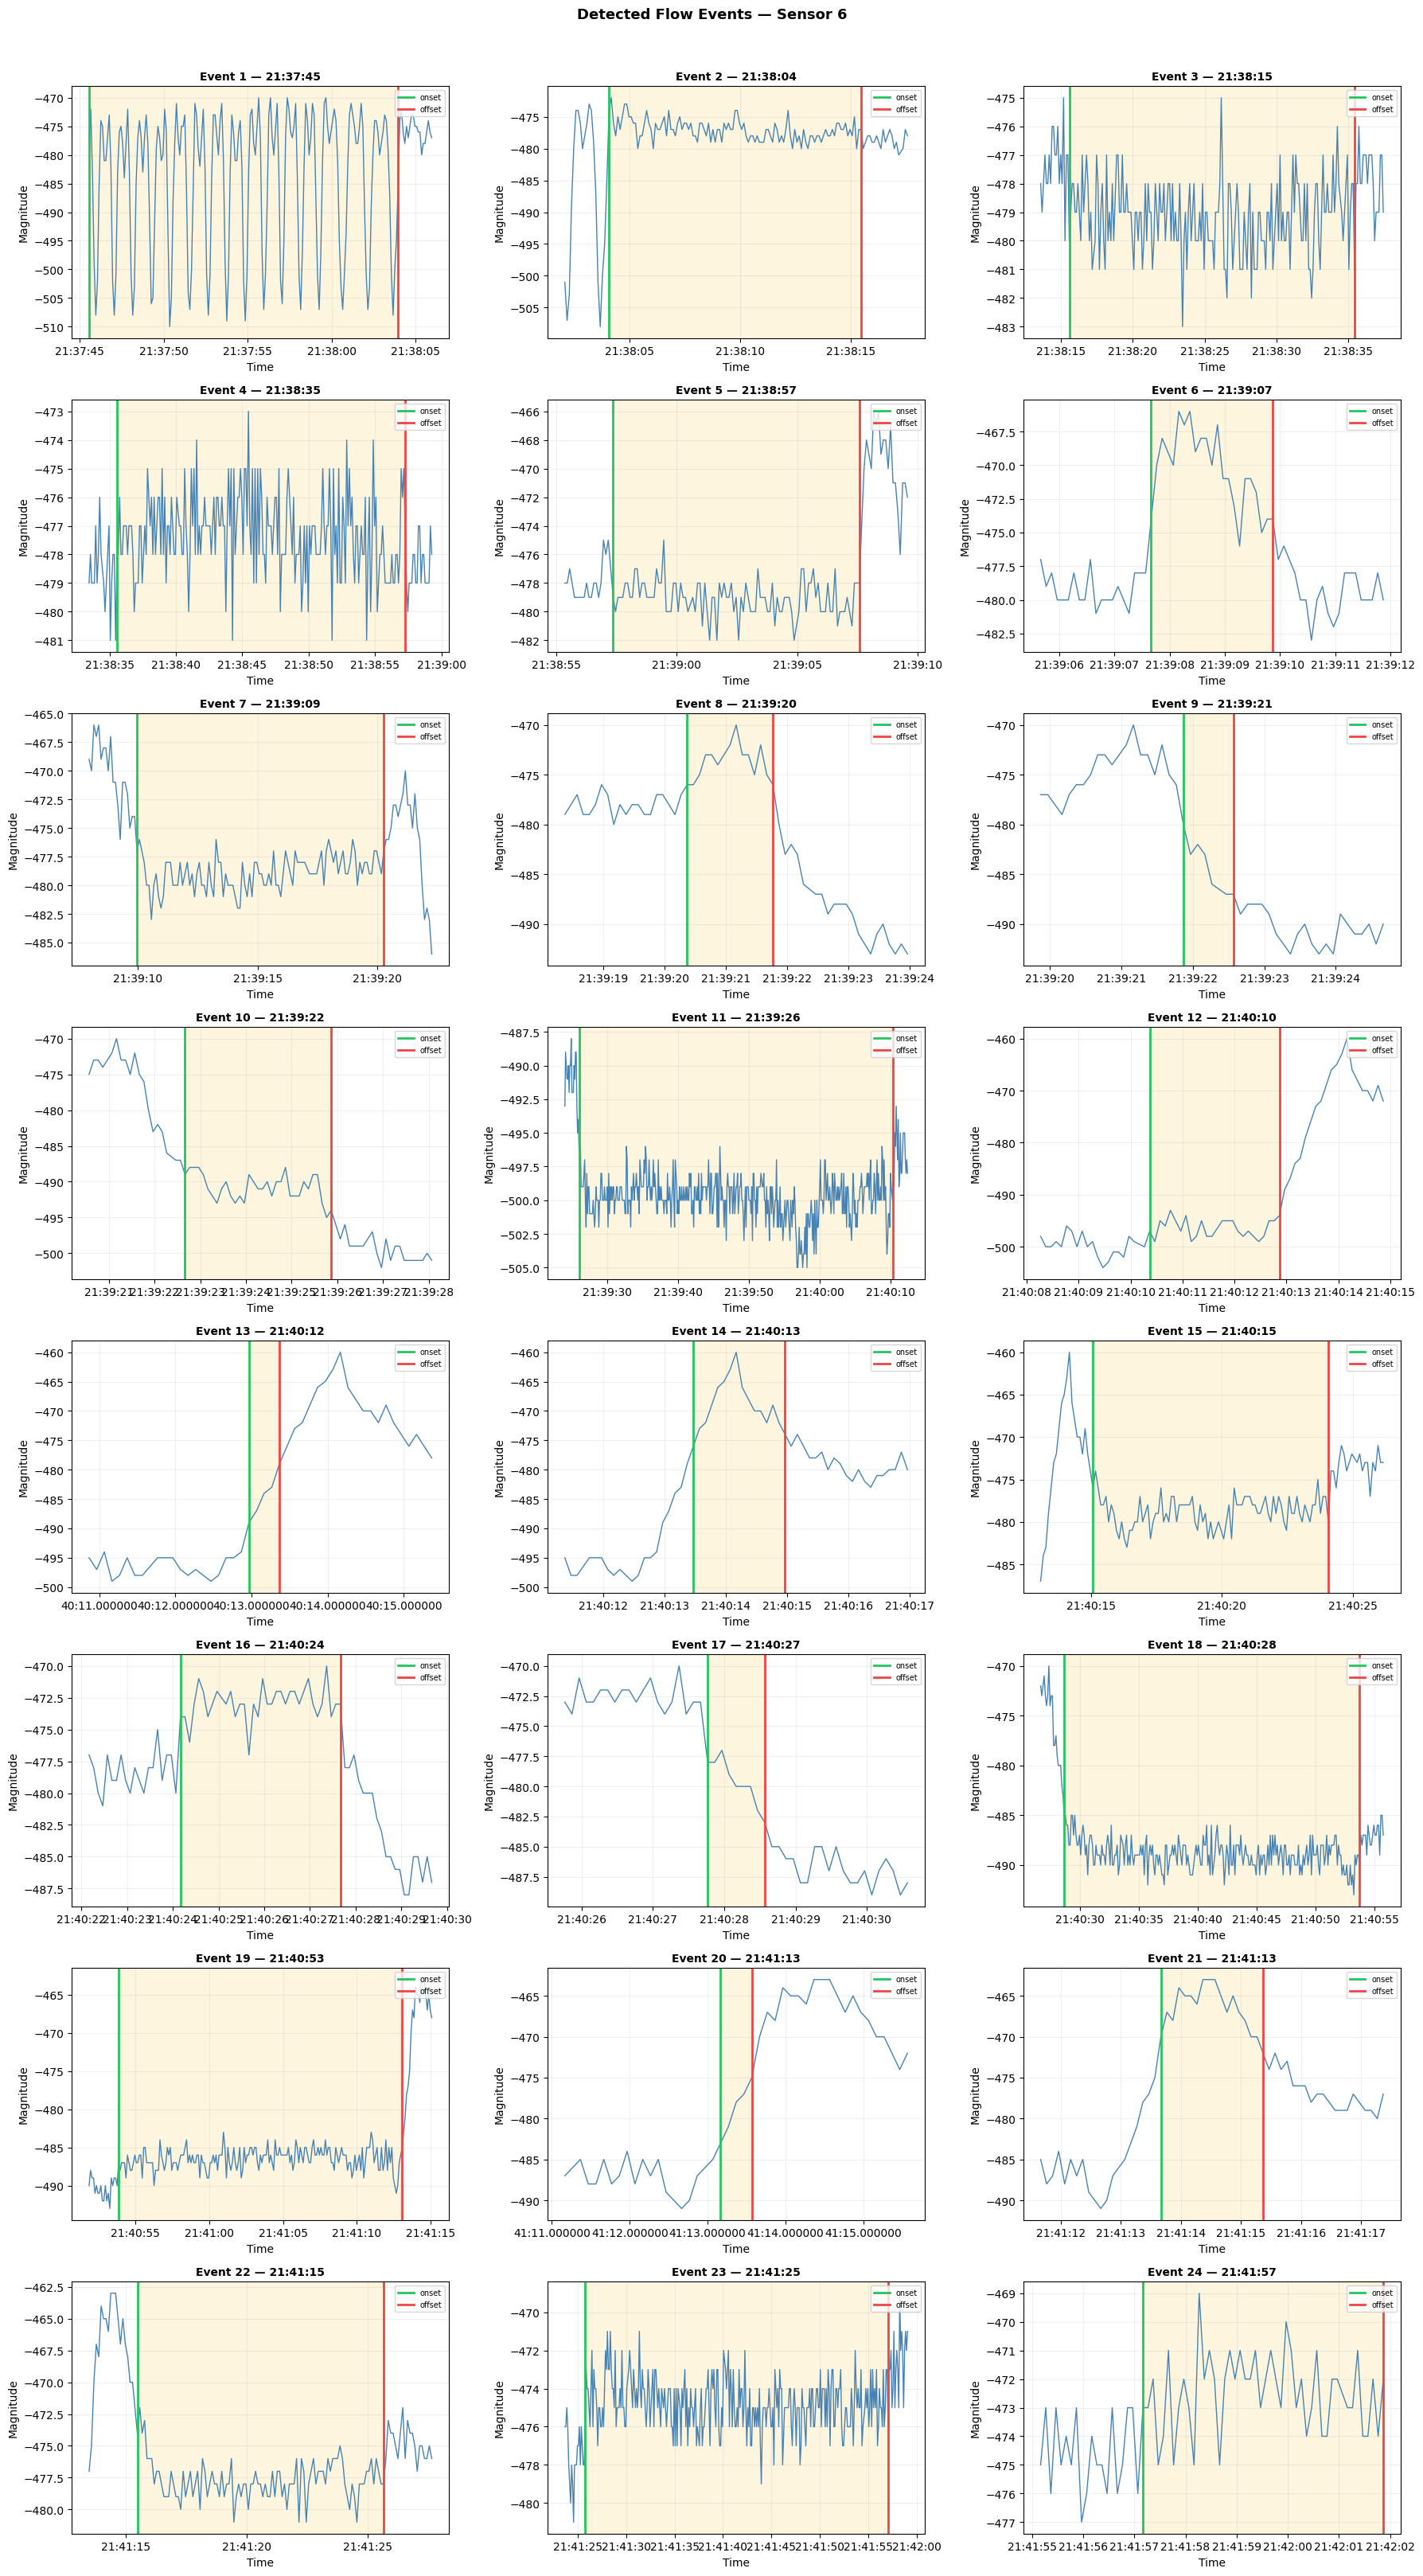

In [33]:
# Zoom plots for each detected event (with some padding)
PAD = 20  # extra samples before/after each event for context

n_events = len(events)
if n_events > 0:
    cols = min(3, n_events)
    rows = (n_events + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), squeeze=False)
    
    for i, ev in enumerate(events):
        ax = axes[i // cols, i % cols]
        lo = max(0, ev["start"] - PAD)
        hi = min(len(signal), ev["end"] + PAD)
        
        ax.plot(ts_plot[lo:hi], signal[lo:hi], lw=1, color="steelblue")
        ax.axvline(ts_plot[ev["start"]], color="#22c55e", lw=2, ls="-", label="onset")
        ax.axvline(ts_plot[min(ev["end"] - 1, len(ts_plot) - 1)], color="#ef4444", lw=2, ls="-", label="offset")
        ax.axvspan(ts_plot[ev["start"]], ts_plot[min(ev["end"] - 1, len(ts_plot) - 1)],
                   color="#fbbf24", alpha=0.15)
        
        t0 = pd.Timestamp(timestamps[ev['start']])
        ax.set_title(f"Event {i+1} — {t0.strftime('%H:%M:%S')}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Time")
        ax.set_ylabel("Magnitude")
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(True, alpha=0.2)
    
    # Hide unused subplots
    for i in range(n_events, rows * cols):
        axes[i // cols, i % cols].set_visible(False)
    
    plt.suptitle(f"Detected Flow Events — Sensor {SENSOR_ID}", fontweight="bold", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No active events detected — try lowering the PENALTY parameter.")